<a href="https://colab.research.google.com/github/SharvariDatir5/UST_Onboarding_Assignment/blob/main/PS1%20TRIAL2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PS1


In [1]:
# Install dependencies
!pip install torch torchvision opencv-python matplotlib
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17898, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 17898 (delta 61), reused 40 (delta 40), pack-reused 17818 (from 2)
Receiving objects: 100% (17898/17898), 17.03 MiB | 8.67 MiB/s, done.
Resolving deltas: 100% (12192/12192), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 10.8 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [2]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load MiDaS model
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.eval()

# Load transforms
transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = transforms.small_transform

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [01:47<00:00, 795kB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [4]:
# Load YOLOv5
yolo_model = torch.hub.load('ultralytics/yolov5', 'yolov5s')

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 2026-5-1 Python-3.12.13 torch-2.10.0+cpu CPU

100%|██████████| 14.1M/14.1M [00:00<00:00, 39.8MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [8]:
from google.colab import files
uploaded = files.upload()

Saving test.jpg.png to test.jpg.png


In [14]:
from google.colab import files
uploaded = files.upload()

# Get correct uploaded filename
image_path = list(uploaded.keys())[0]

print("Using image:", image_path)

# Read image
img = cv2.imread(image_path)

# Check if loaded properly
if img is None:
    raise ValueError("❌ Image not loaded. Check file name.")

# Convert to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show input image
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Input Image")
plt.show()

Saving test.jpg.png to test.jpg (1).png
Using image: test.jpg (1).png


In [11]:
# Prepare input
input_batch = transform(img_rgb)

# Prediction
with torch.no_grad():
    prediction = midas(input_batch)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img_rgb.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

depth_map = prediction.cpu().numpy()

# Normalize for visualization
depth_map = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min())

plt.imshow(depth_map, cmap='inferno')
plt.colorbar()
plt.title("Depth Map")

Text(0.5, 1.0, 'Depth Map')

In [12]:
results = yolo_model(img_rgb)
detections = results.xyxy[0]  # bounding boxes

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [13]:
for *box, conf, cls in detections:
    x1, y1, x2, y2 = map(int, box)

    label = yolo_model.names[int(cls)]

    # Focus on vehicles
    if label in ["car", "truck", "bus"]:

        # Extract depth region
        obj_depth = depth_map[y1:y2, x1:x2]
        avg_depth = np.mean(obj_depth)

        # Convert to pseudo distance
        distance = 1 / (avg_depth + 1e-6)

        print(f"{label} detected at approx distance: {distance:.2f}")

        # Draw bounding box
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img, f"{label} {distance:.2f}",
                    (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0,255,0), 2)

truck detected at approx distance: 2.17
truck detected at approx distance: 1.64
car detected at approx distance: 2.20
truck detected at approx distance: 1.68


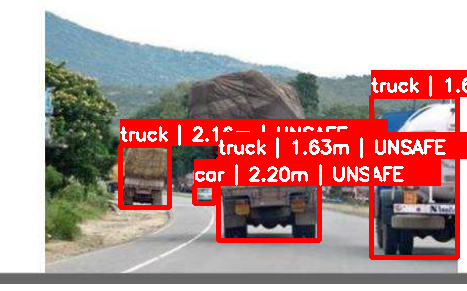

✅ DONE: Image displayed + saved


In [15]:
# ===============================
# FINAL OUTPUT BLOCK (WORKING)
# ===============================

# Make sure image is loaded
if img is None:
    raise ValueError("❌ Image not loaded properly")

output_img = img.copy()

vehicle_classes = ["car", "truck", "bus", "motorcycle"]
SAFE_DISTANCE = 15

for *box, conf, cls in detections:
    x1, y1, x2, y2 = map(int, box)
    label = yolo_model.names[int(cls)]

    if label in vehicle_classes:

        obj_depth = depth_map[y1:y2, x1:x2]

        if obj_depth.size == 0:
            continue

        avg_depth = np.median(obj_depth)

        if avg_depth < 0.01:
            continue

        distance = 1 / (avg_depth + 1e-6)

        if distance < SAFE_DISTANCE:
            color = (0, 0, 255)
            status = "UNSAFE"
        else:
            color = (0, 255, 0)
            status = "SAFE"

        # Draw box
        cv2.rectangle(output_img, (x1, y1), (x2, y2), color, 4)

        text = f"{label} | {distance:.2f}m | {status}"

        (w, h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)

        cv2.rectangle(output_img,
                      (x1, max(30, y1 - h - 10)),
                      (x1 + w, y1),
                      color,
                      -1)

        cv2.putText(output_img,
                    text,
                    (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255, 255, 255),
                    2)

# Convert to RGB for display
output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

# 🔥 FORCE DISPLAY (IMPORTANT)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.imshow(output_rgb)
plt.axis('off')
plt.show()

# Save output
cv2.imwrite("final_output.jpg", output_img)

# ALSO DISPLAY USING OPENCV (EXTRA SAFE METHOD)
from google.colab.patches import cv2_imshow
cv2_imshow(output_img)

print("✅ DONE: Image displayed + saved")

✅ Clean output saved as final_output_clean.jpg


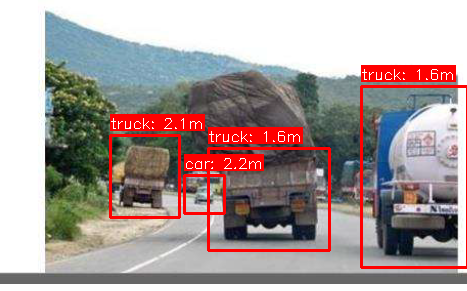

In [17]:
output_img = img.copy()

vehicle_classes = ["car", "truck", "bus", "motorcycle"]
SAFE_DISTANCE = 15

for *box, conf, cls in detections:
    x1, y1, x2, y2 = map(int, box)
    label = yolo_model.names[int(cls)]

    # 🔹 Filter weak detections
    if conf < 0.4:
        continue

    if label in vehicle_classes:

        # 🔹 Expand bounding box slightly (to cover full truck)
        padding = 10
        x1 = max(0, x1 - padding)
        y1 = max(0, y1 - padding)
        x2 = min(img.shape[1], x2 + padding)
        y2 = min(img.shape[0], y2 + padding)

        obj_depth = depth_map[y1:y2, x1:x2]

        if obj_depth.size == 0:
            continue

        avg_depth = np.median(obj_depth)

        if avg_depth < 0.01:
            continue

        distance = 1 / (avg_depth + 1e-6)

        # 🔴 Use RED only (as you requested)
        color = (0, 0, 255)

        # Draw clean rectangle
        cv2.rectangle(output_img, (x1, y1), (x2, y2), color, 2)

        # 🔹 Smaller clean text
        text = f"{label}: {distance:.1f}m"

        font_scale = 0.5
        thickness = 1

        (w, h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)

        # 🔹 Position text ABOVE box properly
        y_text = max(20, y1 - 5)

        # Background box (small & clean)
        cv2.rectangle(output_img,
                      (x1, y_text - h - 4),
                      (x1 + w, y_text),
                      color,
                      -1)

        # White text
        cv2.putText(output_img,
                    text,
                    (x1, y_text - 2),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    font_scale,
                    (255, 255, 255),
                    thickness)

# Convert to RGB
output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12,8))
plt.imshow(output_rgb)
plt.axis('off')
plt.title("Improved Detection Output")
plt.show()

# Save image
cv2.imwrite("final_output_clean.jpg", output_img)

print("✅ Clean output saved as final_output_clean.jpg")

from google.colab.patches import cv2_imshow
cv2_imshow(output_img)